In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv('data/processed/02_nav_history_clean.csv')

nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

In [2]:
risk_metrics = []

for fund, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    var95 = np.percentile(returns,5)

    cvar95 = returns[returns <= var95].mean()

    risk_metrics.append([fund,var95,cvar95])

risk_df = pd.DataFrame(
    risk_metrics,
    columns=['amfi_code','VaR_95','CVaR_95']
)

risk_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [4]:
risk_df.to_csv("var_cvar_report.csv",index=False)

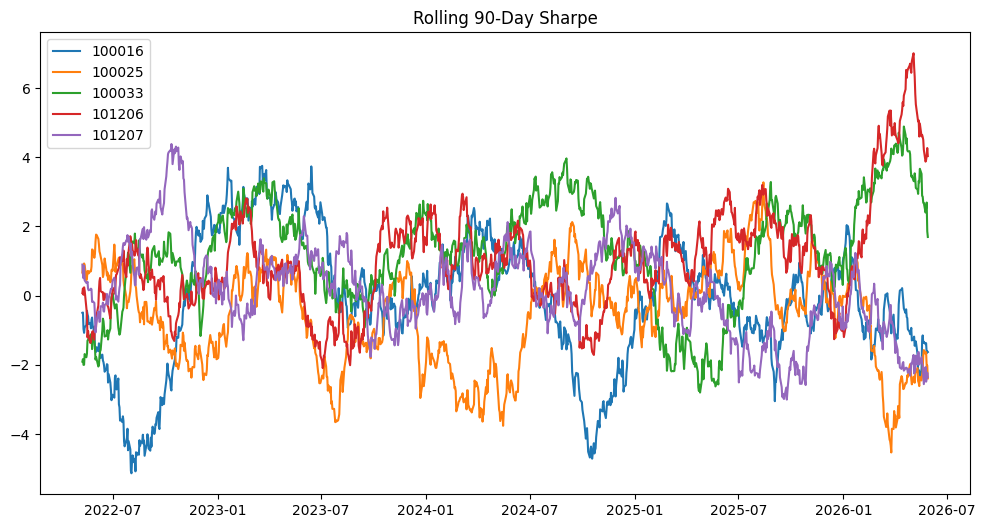

In [5]:
import matplotlib.pyplot as plt

rf_daily = 0.065/252

top5 = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(12,6))

for fund in top5:

    temp = nav[nav['amfi_code']==fund].copy()

    returns = temp['daily_return']

    rolling_sharpe = (
        (returns.rolling(90).mean()-rf_daily)
        /
        returns.rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(temp['date'],rolling_sharpe,label=str(fund))

plt.legend()

plt.title("Rolling 90-Day Sharpe")

plt.savefig("rolling_sharpe_chart.png")

plt.show()

In [6]:
tx = pd.read_csv(
'data/processed/08_investor_transactions_clean.csv'
)

tx['transaction_date'] = pd.to_datetime(tx['transaction_date'])

tx['cohort_year'] = tx.groupby(
'investor_id'
)['transaction_date'].transform('min').dt.year

cohort = tx.groupby('cohort_year').agg(

avg_sip_amount=('amount_inr','mean'),

total_invested=('amount_inr','sum')

)

cohort

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [7]:
sip = tx[
tx['transaction_type']=="SIP"
].copy()

sip = sip.sort_values(
['investor_id','transaction_date']
)

sip['gap_days'] = sip.groupby(
'investor_id'
)['transaction_date'].diff().dt.days

risk_investors = (
sip.groupby('investor_id')
['gap_days']
.mean()
.reset_index()
)

risk_investors['status'] = np.where(

risk_investors['gap_days']>35,

"At Risk",

"Healthy"

)

risk_investors.head()

,investor_id,gap_days,status
0,INV000001,76.0,At Risk
1,INV000002,207.0,At Risk
2,INV000003,238.0,At Risk
3,INV000004,85.4,At Risk
4,INV000005,14.0,Healthy


In [8]:
import pandas as pd

holdings = pd.read_csv('data/processed/09_portfolio_holdings_clean.csv')

print(holdings.columns)
holdings.head()

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [9]:
sector_weights = holdings.groupby(
    ['amfi_code', 'sector']
)['weight_pct'].sum().reset_index()

sector_weights.head()

,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90


In [11]:
sector_weights['weight'] = sector_weights['weight_pct'] / 100

In [12]:
hhi = sector_weights.groupby('amfi_code')['weight'].apply(
    lambda x: (x**2).sum()
).reset_index()

hhi.columns = ['amfi_code', 'HHI']

hhi.head()

,amfi_code,HHI
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [13]:
hhi = hhi.sort_values('HHI', ascending=False)

print(hhi.head(10))

    amfi_code       HHI
11     119092  0.296769
30     148569  0.254992
27     125498  0.253155
6      102887  0.251383
32     149323  0.241077
21     120505  0.238695
10     118635  0.237497
18     119599  0.232361
22     120506  0.231464
1      100033  0.227647


In [14]:
hhi.to_csv('sector_hhi_report.csv', index=False)

## Insight 1

Historical VaR and CVaR analysis indicate that some schemes exhibit significantly higher downside risk during adverse market conditions.

## Insight 2

Rolling 90-day Sharpe ratios show that risk-adjusted performance changes over time, with some funds consistently outperforming others.

## Insight 3

Investor cohort analysis reveals that newer cohorts contribute higher average investment amounts and larger total investments.

## Insight 4

SIP continuity analysis identified investors with average gaps exceeding 35 days, indicating potential attrition risk.

## Insight 5

Sector concentration analysis shows that fund 119092 has the highest HHI value (0.2968), followed by funds 148569 and 125498, indicating relatively concentrated portfolios and higher sector-specific exposure.